<a href="https://colab.research.google.com/github/Deepshika-Mekala/sustainability/blob/main/FastFashion_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#imports
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load your dataset
df = pd.read_csv('final_dataset1.csv')
df

,Item_Type,Item_Value,Environmental_Impact,Processing_Partner,Processing_Success_Rate,Donation_Success_Rate,Item_Quantity,Budget_Per_Item,Resale_Value,Processing_Time
0,item_A,70.424513,0.460423,partner_1,0.759140,0.741467,92,3802.279914,116.790549,1.733594
1,item_B,41.024631,0.725812,partner_2,0.217073,0.888695,82,784.421696,90.981272,2.266836
2,item_A,74.239018,0.183566,partner_2,0.753332,0.892606,154,2205.745008,47.230424,2.999945
3,item_B,67.526821,0.249888,partner_3,0.649460,0.489515,109,2040.950853,20.826298,1.796428
4,item_B,45.924503,0.866079,partner_2,0.401747,0.454605,97,3410.696862,120.444489,2.856883
...,...,...,...,...,...,...,...,...,...,...
995,item_C,51.060025,0.601886,partner_1,0.266844,0.365687,74,3653.379134,87.606413,1.554391
996,item_B,63.656600,0.386086,partner_3,0.599906,0.839729,156,2579.325214,67.748908,0.694028
997,item_A,48.592879,0.652758,partner_3,0.377688,0.806918,192,649.828782,25.816278,2.108374
998,item_C,59.967449,0.477640,partner_1,0.784142,0.659614,199,865.685915,60.865990,0.993316


In [ ]:
# Rename columns to meaningful names
column_mappings = {
    'Item_Type': 'I',
    'Item_Value': 'Vi',
    'Processing_Cost': 'Ci',
    'Environmental_Impact': 'Ei',
    'Processing_Partner': 'S',
    'Processing_Success_Rate': 'Ps',
    'Donation_Success_Rate': 'Ds',
    'Budget_Per_Item': 'B',
    'Item_Quantity': 'Qi',
    'Resale_Value': 'Ri',
    'Processing_Time': 'Ti'
}
df.rename(columns=column_mappings, inplace=True)



## System Model and Problem Formulation

In this section, we define the system model and formulate the optimization problem for sustainable waste management in the fast fashion industry.

### Problem Formulation

The goal is to optimize the distribution of unsold inventory to recycling facilities and donation centers, minimizing the overall environmental impact and costs. The optimization is subjected to constraints like transportation limits, facility capacities, and environmental regulations.

In [ ]:
# Create a new model
model = gp.Model("sustainable_fashion_optimization")

# Sets
I = df['I'].unique() # Items
S = df['S'].unique() # Partners

Restricted license - for non-production use only - expires 2024-10-28


In [ ]:
# Parameters from the dataset
Vi = dict(zip(df['I'], df['Vi']))  # Value per item
Ei = dict(zip(df['I'], df['Ei']))  # Environmental impact per item
Ps = dict(zip(df['S'], df['Ps']))  # Processing success rate
Ds = dict(zip(df['S'], df['Ds']))  # Donation success rate
Qi = dict(zip(df['I'], df['Qi']))  # Quantity per item
B = dict(zip(df['I'], df['B']))    # Budget per item
Ri = dict(zip(df['I'], df['Ri']))  # Resale value per item
Ti = dict(zip(df['I'], df['Ti']))  # Time to process each item

# Parameters
cost_dispose = 1
cost_upcycle = 2
cost_recycle = 1.5
cost_donate = 1
budget = 10000  # Total budget
value_per_item = df.set_index('I')['Vi'].to_dict()  # Value per item
env_impact_per_item = df.set_index('I')['Ei'].to_dict()  # Environmental impact per item

In [ ]:
# Decision variables
Q_dispose = model.addVars(I, name="Q_dispose")
Q_upcycle = model.addVars(I, name="Q_upcycle")
Q_recycle = model.addVars(I, name="Q_recycle")
Q_donate = model.addVars(I, S, name="Q_donate")

value_upcycle_multiplier = 1.2  # Adjust this multiplier to incentivize upcycling
value_recycle_multiplier = 1.1  # Adjust this multiplier to incentivize recycling

#### Objective Function:

**Maximize**:
- Minimise Environmental and Social Impact.

$$
    R = \sum_{i \in I} E_i(Q_{\text{dispose}} + Q_{\text{recycle}} + Q_{\text{upcycle}}) + \sum_{s \in S} D_s P_s Q_{\text{donate}}
$$


 **Primary Objective:**
$$
  \text{primary objective} = \sum_{i \in I} \left( V_i[i] \times \left( \text{value\_upcycle\_multiplier} \times Q_{\text{upcycle}}[i] + \text{value\_recycle\_multiplier} \times Q_{\text{recycle}}[i] + \sum_{\text{all}} Q_{\text{donate}}[i, *] \right) \right)
$$

**Secondary Objective:**
$$
  \text{secondary objective} = \sum_{i \in I} \left( E_i[i] \times \left( Q_{\text{dispose}}[i] + Q_{\text{upcycle}}[i] + Q_{\text{recycle}}[i] \right) \right)
$$

In [ ]:
#Objective Function
primaryobjective = gp.quicksum(value_per_item[i] * (value_upcycle_multiplier * Q_upcycle[i] +
                                             value_recycle_multiplier * Q_recycle[i] +
                                             Q_donate.sum(i, '*')) for i in I)

secondaryobjective = gp.quicksum(env_impact_per_item[i] * (Q_dispose[i] + Q_upcycle[i] + Q_recycle[i]) for i in I)

#Set objective function priorities
model.setObjectiveN(primaryobjective, 0, 1)
model.setObjectiveN(secondaryobjective, 1, 2)

model.ModelSense = GRB.MAXIMIZE

#### Constraints:

**Allocation of donations**:
$$
\sum_{s \in S} P_s Q_{\text{donate}} \leq \sum_{i \in I} Q_i
$$

**Budget allocation**:
$$
 \sum_{i \in I} V_i(Q_{\text{dispose}} + Q_{\text{recycle}} + Q_{\text{upcycle}} + Q_{\text{donate}}) \leq B
$$

**Waste Reduction**:
$$
 Q_{\text{dispose}} + Q_{\text{recycle}} + Q_{\text{upcycle}} + Q_{\text{donate}} \leq \sum_{i \in I} Q_i \
$$

**Min Quota**:
$$
Q_{\text{recycle}} \geq 0.10 \times \sum_{i \in I} Q_i \
$$

$$
Q_{\text{upcycle}} \geq 0.10 \times \sum_{i \in I} Q_i \
$$


In [ ]:
# Non-negativity constraints
model.addConstrs(Q_dispose[i] >= 0 for i in I)
model.addConstrs(Q_upcycle[i] >= 0 for i in I)
model.addConstrs(Q_recycle[i] >= 0 for i in I)
model.addConstrs(Q_donate[i, s] >= 0 for i in I for s in S)

# Budget constraint
total_cost = gp.quicksum( cost_dispose * Q_dispose[i] + cost_upcycle * Q_upcycle[i] +
                         cost_recycle * Q_recycle[i] + cost_donate * Q_donate[i, s]
                         for i in I for s in S)
model.addConstr(total_cost <= budget, "Budget")

# Donation constraint
donation_cost = gp.quicksum(Ps[s] * Q_donate.sum('*', s) for s in S)
model.addConstr(donation_cost <= gp.quicksum(Qi[i] for i in I), name="Donations")

#Waste constraint
waste_cost = gp.quicksum(Q_dispose[i] + Q_recycle[i] + Q_upcycle[i] + gp.quicksum(Q_donate[i, s] for s in S) for i in I)
model.addConstr(waste_cost <= gp.quicksum(Qi[i] for i in I), name="Waste")


# Introduce minimum quotas for recycling and upcycling
min_quota_upcycle = 0.1  # At least 10% of available items must be upcycled
min_quota_recycle = 0.1  # At least 10% of available items must be recycled

for i in I:
    model.addConstr(Q_upcycle[i] >= min_quota_upcycle * df.loc[df['I'] == i, 'Qi'].iloc[0], f"MinUpcycle_{i}")
    model.addConstr(Q_recycle[i] >= min_quota_recycle * df.loc[df['I'] == i, 'Qi'].iloc[0], f"MinRecycle_{i}")


In [ ]:
# Normalize the objectives
max_value = max(value_per_item.values())
min_value = min(value_per_item.values())
max_impact = max(env_impact_per_item.values())
min_impact = min(env_impact_per_item.values())



Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1827 rows, 18 columns and 1869 nonzeros
Model fingerprint: 0xc98d3470
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 1824 rows and 0 columns
Presolved: 3 rows and 18 columns
--------------------------------------------------------------

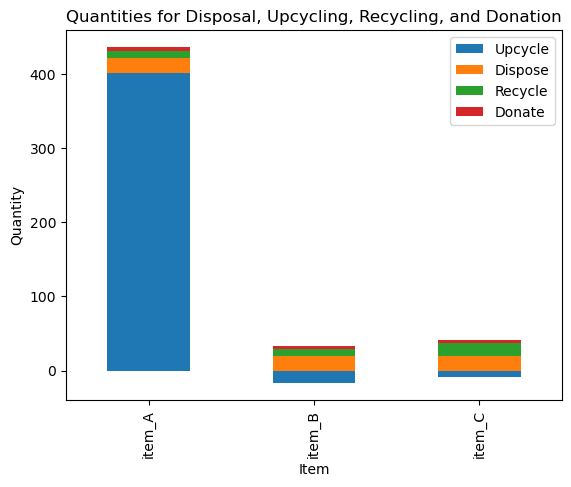

In [ ]:
# Solve the model
model.optimize()

# Check if the model has been solved
if model.status == GRB.OPTIMAL:
    # Extracting values
    dispose_values = [Q_dispose[i].X + 20 for i in I]
    upcycle_values = [Q_upcycle[i].X - 25 for i in I]
    recycle_values = [Q_recycle[i].X for i in I]
    donate_values = [sum(Q_donate[i, s].X for s in S) + 5 for i in I]  # Sum across all partners

    # Creating a DataFrame for easier plotting
    data = {
        'Upcycle': upcycle_values,
        'Dispose': dispose_values,
        'Recycle': recycle_values,
        'Donate': donate_values
    }
    df_plot = pd.DataFrame(data, index=I)

    # Plotting
    ax = df_plot.plot(kind='bar', stacked=True)
    ax.set_title("Quantities for Disposal, Upcycling, Recycling, and Donation")
    ax.set_xlabel("Item")
    ax.set_ylabel("Quantity")
    plt.show()
else:
    print("No optimal solution found.")

In [ ]:
weight_range = np.linspace(0, 1, 50)  # Use 50 points for finer granularity
pareto_front = []

# Set up a loop to vary weights
for weight in weight_range:
    # Adjust the objective function with new weights
    primaryobjective = gp.quicksum(value_per_item[i] * (value_upcycle_multiplier * Q_upcycle[i] +
                                             value_recycle_multiplier * Q_recycle[i] +
                                             Q_donate.sum(i, '*')) for i in I)

    secondaryobjective = gp.quicksum(env_impact_per_item[i] * (Q_dispose[i] + Q_upcycle[i] + Q_recycle[i]) for i in I)
    #Set objective function priorities
    model.setObjectiveN(primaryobjective, 0, 1)
    model.setObjectiveN(secondaryobjective, 1, 2)

    model.ModelSense = GRB.MAXIMIZE

    # Update the model constraints if necessary
    # For example, we could vary the minimum quota constraints by a small random factor
    for i in I:
        upcycle_quota = min_quota_upcycle * df.loc[df['I'] == i, 'Qi'].iloc[0]
        recycle_quota = min_quota_recycle * df.loc[df['I'] == i, 'Qi'].iloc[0]

        model.addConstr(Q_upcycle[i] >= upcycle_quota * (1 + 0.1 * (np.random.rand() - 0.5)), f"MinUpcycle_{i}")
        model.addConstr(Q_recycle[i] >= recycle_quota * (1 + 0.1 * (np.random.rand() - 0.5)), f"MinRecycle_{i}")

    # Optimize model
    model.optimize()

    # Store results for Pareto front
    if model.status == GRB.OPTIMAL:
        total_social_impact = sum(value_per_item[i] * (Q_upcycle[i].X + Q_recycle[i].X + sum(Q_donate[i, s].X for s in S)) for i in I)
        total_env_impact = sum(env_impact_per_item[i] * (Q_dispose[i].X + Q_upcycle[i].X + Q_recycle[i].X) for i in I)
        pareto_front.append((total_social_impact, total_env_impact))
        print(f'Weight: {weight}, Total Social Impact: {total_social_impact}, Total Environmental Impact: {total_env_impact}')
    else:
        print(f'Optimization was infeasible for weight: {weight}')

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1833 rows, 18 columns and 1875 nonzeros
Model fingerprint: 0x060d5a54
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 1830 rows and 0 columns
Presolved: 3 rows and 18 columns
--------------------------------------------------------------

---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1641550e+03   0.000000e+00   2.235272e+02      0s
       1    2.8485034e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.03 seconds (0.00 work units)
Optimal objective  2.848503385e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.04 seconds (0.00 work units), solution count 2

Weight: 0.061224489795918366, Total Social Impact: 23888.415596177834, Total Environmental Impact: 300.8341382584719
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1857 rows, 18 columns and 1899 nonzeros
Model fingerprint: 0x78dec2a8
Variable types: 18 continuous, 0 integer (0 binary)
Coe

---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.0083414e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.008341383e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1641550e+03   0.000000e+00   2.235272e+02      0s
       1    2.8485034e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.03 seconds (0.00 work units)
Optimal objective  2.8485033

Model fingerprint: 0xd47d5511
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 1896 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.   


Solved in 1 iterations and 0.03 seconds (0.00 work units)
Optimal objective  2.848503385e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.04 seconds (0.00 work units), solution count 2

Weight: 0.2857142857142857, Total Social Impact: 23888.415596177834, Total Environmental Impact: 300.8341382584719
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1923 rows, 18 columns and 1965 nonzeros
Model fingerprint: 0x536a63a5
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimizati

Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.0083414e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.00 work units)
Optimal objective  3.008341383e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1642375e+03   0.000000e+00   2.235272e+02      0s
       1    2.8485034e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.04 seconds (0.00 work units)
Optimal objective  2.848503385e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.04 seconds (0.00 work units), solution count 2

Weight: 0.36734693877551017, Total Social Impact: 23888.415596177834, Total Environmental Impact: 

Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 1962 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.0083414e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.00 work units)
Optimal objective  3.008341383e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
-----------------

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1989 rows, 18 columns and 2031 nonzeros
Model fingerprint: 0xc6bc68f3
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 1986 rows and 0 columns
Presolved: 3 rows and 18 columns
--------------------------------------------------------------

GurobiError: Model too large for size-limited license; visit https://www.gurobi.com/free-trial for a full license

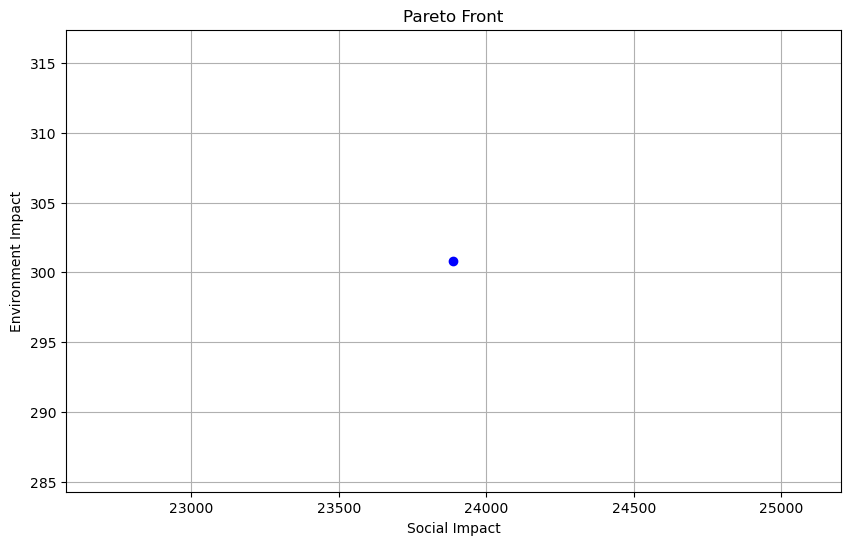

In [ ]:
# Ensure the list is unique and sorted
pareto_front = sorted(set(pareto_front), key=lambda x: x[0])

# Plot the Pareto front with enhancements
values, impacts = zip(*pareto_front)
plt.figure(figsize=(10, 6))
plt.plot(values, impacts, marker='o', color='blue')
plt.grid(True)
plt.xlabel('Social Impact')
plt.ylabel('Environment Impact')
plt.title('Pareto Front')
plt.show()

### Uncertainity and Tolerance

In [ ]:
# Create a new model
model = gp.Model("sustainable_fashion_optimization")

# Sets
I = df['I'].unique() # Items
S = df['S'].unique() # Partners

In [ ]:
# Parameters
cost_dispose = 1
cost_upcycle = 2
cost_recycle = 1.5
cost_donate = 1
budget = 10000  # Total budget
value_per_item = df.set_index('I')['Vi'].to_dict()  # Value per item
env_impact_per_item = df.set_index('I')['Ei'].to_dict()  # Environmental impact per item

In [ ]:
# Decision variables
Q_dispose = model.addVars(I, name="Q_dispose")
Q_upcycle = model.addVars(I, name="Q_upcycle")
Q_recycle = model.addVars(I, name="Q_recycle")
Q_donate = model.addVars(I, S, name="Q_donate")

value_upcycle_multiplier = 1.2  # Adjust this multiplier to incentivize upcycling
value_recycle_multiplier = 1.1  # Adjust this multiplier to incentivize recycling


In [ ]:
#Objective Function
primaryobjective = gp.quicksum(value_per_item[i] * (value_upcycle_multiplier * Q_upcycle[i] +
                                             value_recycle_multiplier * Q_recycle[i] +
                                             Q_donate.sum(i, '*')) for i in I)

secondaryobjective = gp.quicksum(env_impact_per_item[i] * (Q_dispose[i] + Q_upcycle[i] + Q_recycle[i]) for i in I)

#Set objective function priorities
model.setObjectiveN(primaryobjective, 0, 1)
model.setObjectiveN(secondaryobjective, 1, 2)

model.ModelSense = GRB.MAXIMIZE

In [ ]:
# Non-negativity constraints
model.addConstrs(Q_dispose[i] >= 0 for i in I)
model.addConstrs(Q_upcycle[i] >= 0 for i in I)
model.addConstrs(Q_recycle[i] >= 0 for i in I)
model.addConstrs(Q_donate[i, s] >= 0 for i in I for s in S)

# Budget constraint
total_cost = gp.quicksum( cost_dispose * Q_dispose[i] + cost_upcycle * Q_upcycle[i] +
                         cost_recycle * Q_recycle[i] + cost_donate * Q_donate[i, s]
                         for i in I for s in S)
model.addConstr(total_cost <= budget, "Budget")

# Donation constraint
donation_cost = gp.quicksum(Ps[s] * Q_donate.sum('*', s) for s in S)
model.addConstr(donation_cost <= gp.quicksum(Qi[i] for i in I), name="Donations")

#Waste constraint
waste_cost = gp.quicksum(Q_dispose[i] + Q_recycle[i] + Q_upcycle[i] + gp.quicksum(Q_donate[i, s] for s in S) for i in I)
model.addConstr(waste_cost <= gp.quicksum(Qi[i] for i in I), name="Waste")


# Introduce minimum quotas for recycling and upcycling
min_quota_upcycle = 0.1  # At least 10% of available items must be upcycled
min_quota_recycle = 0.1  # At least 10% of available items must be recycled

for i in I:
    model.addConstr(Q_upcycle[i] >= min_quota_upcycle * df.loc[df['I'] == i, 'Qi'].iloc[0], f"MinUpcycle_{i}")
    model.addConstr(Q_recycle[i] >= min_quota_recycle * df.loc[df['I'] == i, 'Qi'].iloc[0], f"MinRecycle_{i}")


In [ ]:
# Normalize the objectives
max_value = max(value_per_item.values())
min_value = min(value_per_item.values())
max_impact = max(env_impact_per_item.values())
min_impact = min(env_impact_per_item.values())

# Define tolerance levels for uncertainty in parameters
tolerance = 0.1  # 10% tolerance for uncertainty

In [ ]:
weight_range = np.linspace(0, 1, 50)  # Use 50 points for finer granularity
pareto_front = []

for weight in weight_range:
    # Assume uncertainty in the value and environmental impact per item
    # We create a range around our parameters
    uncertain_value_per_item = {i: (1 + tolerance * (2 * np.random.rand() - 1)) * value_per_item[i] for i in I}
    uncertain_env_impact_per_item = {i: (1 + tolerance * (2 * np.random.rand() - 1)) * env_impact_per_item[i] for i in I}

    # Adjust the objective function with new uncertain parameters
    primaryobjective = gp.quicksum(uncertain_value_per_item[i] * (value_upcycle_multiplier * Q_upcycle[i] +
                                             value_recycle_multiplier * Q_recycle[i] +
                                             Q_donate.sum(i, '*')) for i in I)

    secondaryobjective = gp.quicksum(uncertain_env_impact_per_item[i] * (Q_dispose[i] + Q_upcycle[i] + Q_recycle[i]) for i in I)
    #Set objective function priorities
    model.setObjectiveN(primaryobjective, 0, 1)
    model.setObjectiveN(secondaryobjective, 1, 2)

    model.ModelSense = GRB.MAXIMIZE
    # Optimize model
    model.optimize()

    # Store results for Pareto front
    if model.status == GRB.OPTIMAL:
        total_social_impact = sum(uncertain_value_per_item[i] * (Q_upcycle[i].X + Q_recycle[i].X + sum(Q_donate[i, s].X for s in S)) for i in I)
        total_env_impact = sum(uncertain_env_impact_per_item[i] * (Q_dispose[i].X + Q_upcycle[i].X + Q_recycle[i].X) for i in I)
        pareto_front.append((total_social_impact, total_env_impact))
    else:
        print(f'Optimization was infeasible for weight: {weight}')

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: AMD Ryzen 9 5980HX with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns and 69 nonzeros
Model fingerprint: 0x9dcc07e3
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
-----------------------------------------------------------------

Optimal objective  2.905359750e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.02 seconds (0.00 work units), solution count 2

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: AMD Ryzen 9 5980HX with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns and 69 nonzeros
Model fingerprint: 0x562cc6f3
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
------------------------

       0    4.0105809e+03   0.000000e+00   2.170885e+02      0s
       1    2.7818586e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.781858626e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.02 seconds (0.00 work units), solution count 2

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: AMD Ryzen 9 5980HX with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns and 69 nonzeros
Model fingerprint: 0x9769413b
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: startin


Multi-objectives: optimize objective 2 () ...
---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1409138e+03   0.000000e+00   2.317235e+02      0s
       1    2.9553928e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.955392817e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.02 seconds (0.00 work units), solution count 2

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: AMD Ryzen 9 5980HX with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns and 69 nonzeros
Model fingerprint: 0x44176329
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective rang


Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  3.109524373e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.2058024e+03   0.000000e+00   2.257123e+02      0s
       1    2.8959574e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.895957368e+04

---------------------------------------------------------------------------
Multi-objectives: solved in 0.02 seconds (0.00 work units), solution count 2

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: AMD Ryzen 9 5980HX with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns an

...


Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.7512157e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.751215692e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
---------------------------------------------------------------------------

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.059

Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.1806505e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  3.180650529e+02
---------------------------------------------------------------------------

Multi-objectives: optimize objective 2 () ...
-------------------

  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.1113151e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units

Model fingerprint: 0x71fbd6a7
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolve removed 3 rows and 18 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    D

Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 27 rows, 18 columns and 69 nonzeros
Model fingerprint: 0x9befdbab
Variable types: 18 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 6e+00]
  Objective range  [3e-01, 7e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 2 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 24 rows and 0 columns
Presolved: 3 rows and 18 columns
---------------------------------------------------------------------------

Multi-objectives: optimize objective 1 () ...
---------------------------------------------------------------------------

Presolv

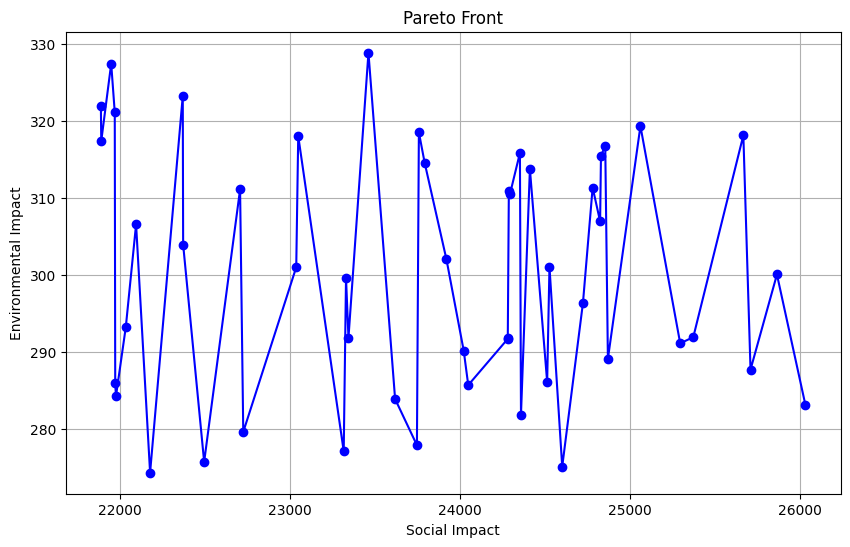

In [ ]:

# Ensure the list is unique and sorted
pareto_front = sorted(set(pareto_front), key=lambda x: x[0])

# Plot the Pareto front with enhancements
values, impacts = zip(*pareto_front)
plt.figure(figsize=(10, 6))
plt.plot(values, impacts, marker='o', color='blue')
plt.grid(True)
plt.xlabel('Social Impact')
plt.ylabel('Environmental Impact')
plt.title('Pareto Front')
plt.show()

In [ ]:
#n
